In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inline plotting for Jupyter
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
path = "/home/asabele/Downloads/Documents/My Data Science Practise/spam.csv"
df = pd.read_csv(path, encoding="latin-1")

# Preprocessing columns
df = df[['v1','v2']]
df.columns = ['label','message']

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


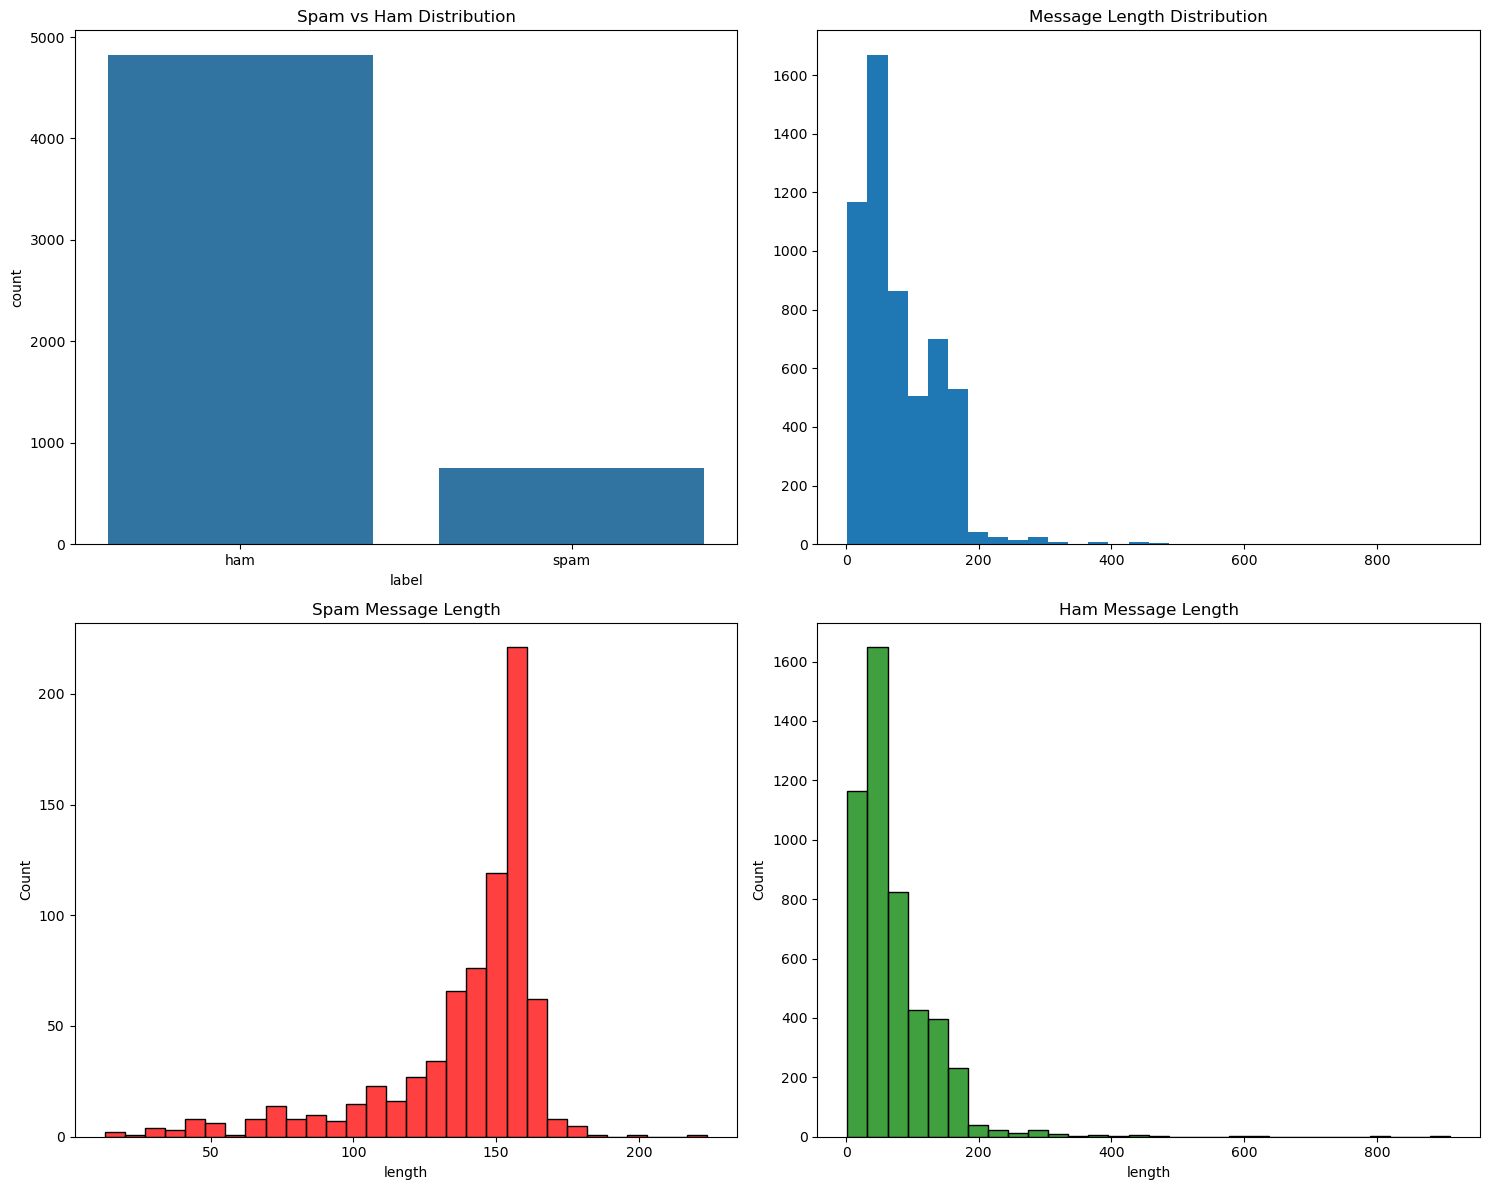

In [3]:
# Create a copy for cleaning and add length feature
df_clean = df.copy()
df_clean['length'] = df_clean['message'].apply(len)

# Visualizations
fig, axes = plt.subplots(2,2, figsize=(15,12))

# 1. Spam vs Ham count
sns.countplot(x=df_clean['label'], ax=axes[0,0])
axes[0,0].set_title("Spam vs Ham Distribution")

# 2. Total Message length distribution
axes[0,1].hist(df_clean['length'], bins=30)
axes[0,1].set_title("Message Length Distribution")

# 3. Spam message length
sns.histplot(df_clean[df_clean['label']=='spam']['length'], bins=30, color='red', ax=axes[1,0])
axes[1,0].set_title("Spam Message Length")

# 4. Ham message length
sns.histplot(df_clean[df_clean['label']=='ham']['length'], bins=30, color='green', ax=axes[1,1])
axes[1,1].set_title("Ham Message Length")

plt.tight_layout()
plt.show()

In [4]:
# Handle missing values and map labels
df_clean = df_clean.dropna()
df_clean['label'] = df_clean['label'].map({'ham': 0, 'spam': 1})

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df_clean['message'])
y = df_clean['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 4457
Test set size: 1115


In [5]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    
    results[name] = {
        'model': model,
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'y_pred': y_pred_test
    }
    
    print(f"{name} Test Accuracy: {results[name]['test_accuracy']:.4f}")

Naive Bayes Test Accuracy: 0.9686
Logistic Regression Test Accuracy: 0.9444


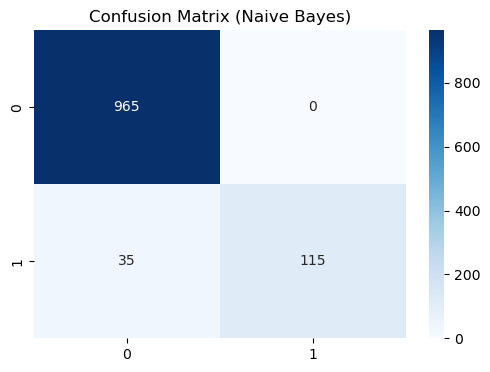

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [6]:
best_model = results['Naive Bayes']['model']
y_pred = results['Naive Bayes']['y_pred']

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Naive Bayes)")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

In [7]:
# Prediction logic
def predict_spam(message):
    vector = vectorizer.transform([message])
    prediction = best_model.predict(vector)[0]
    return "Spam" if prediction == 1 else "Not Spam"

# Test cases
test_msgs = [
    "Congratulations! You won a free iPhone. Click here now!",
    "Hey are we still meeting tomorrow?",
    "URGENT! You have won a $1000 Walmart gift card"
]

for msg in test_msgs:
    print(f"[{predict_spam(msg)}] -> {msg}")

# Save models
joblib.dump(best_model, "spam_detection_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("Model and Vectorizer saved successfully!")

[Spam] -> Congratulations! You won a free iPhone. Click here now!
[Not Spam] -> Hey are we still meeting tomorrow?
[Spam] -> URGENT! You have won a $1000 Walmart gift card
Model and Vectorizer saved successfully!


In [9]:
# --- SIMPLE INPUT-PROCESS-OUTPUT TOOL ---

print("--- Spam Detection System ---")

# 1. INPUT: Request the user to enter the email content
user_input = input("Please paste the email content you suspect to be spam: \n")

if user_input.strip():
    # 2. PROCESS: Use the trained model to analyze the text
    # We use the vectorizer to transform the text and the model to predict
    vectorized_input = vectorizer.transform([user_input])
    prediction = best_model.predict(vectorized_input)[0]
    
    # Optional: Get the probability to see how confident the model is
    # [Note: Some models like Naive Bayes support predict_proba]
    probabilities = best_model.predict_proba(vectorized_input)[0]
    confidence = probabilities[prediction] * 100

    # 3. OUTPUT: Display the outcome
    print("\n--- Processing Result ---")
    if prediction == 1:
        print(f"OUTCOME: SPAM DETECTED, Do not share any of your information, Just delete this fast.")
        print(f"CONFIDENCE: {confidence:.2f}%")
    else:
        print(f"OUTCOME: HAM (Legitimate Email)")
        print(f"CONFIDENCE: {confidence:.2f}%")
else:
    print("Error: No text entered. Please try again.")

--- Spam Detection System ---


Please paste the email content you suspect to be spam: 
 Dear Jacobus VanDer Merwe:  Your verification code for linking your account is:  159409  Please enter this code in - Profile - Account - Link Account to complete the account linking process.  Last War Support Team



--- Processing Result ---
OUTCOME: ✅ HAM (Legitimate Email)
CONFIDENCE: 75.90%
